# 09 — Stage 3 RQ2: Pipeline Comparison (M0 / M1 / M3 / M2)

All routes share the same downstream and the same hold-out common set (n=2,016); they differ only in where the type/year/floor come from.

- **M0** majority baseline · **M1** GT attributes (ceiling) · **M3-{model}** vision attributes → TABULA → LightGBM (decomposed) · **M2-{model}** end-to-end image → label.
- M2-DINOv2 / M2-ResNet50 train a head on the energy label; **M2-VLM is zero-shot** (no training).

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
from _stage3_plot import (REPO, REPORTS_DIR, ENERGY_LABELS, ROUTE_COLORS,
    setup_mpl, save_fig, save_table, load_metrics, confusion_heatmap)
setup_mpl()

ROUTES = ['M0','M1','M3-DINOv2','M3-ResNet50','M3-VLMv3','M2-DINOv2','M2-ResNet50','M2-VLM']
M = {r: load_metrics(r) for r in ROUTES}
print('loaded', list(M.keys()))

loaded ['M0', 'M1', 'M3-DINOv2', 'M3-ResNet50', 'M3-VLMv3', 'M2-DINOv2', 'M2-ResNet50', 'M2-VLM']


## 1. Main comparison table (Table 3)

In [2]:
m1f = M['M1']['macro_f1']; m1k = M['M1']['quadratic_kappa']
rows = []
kind = {'M0':'baseline','M1':'GT ceiling','M3-DINOv2':'decomposed','M3-ResNet50':'decomposed',
        'M3-VLMv3':'decomposed','M2-DINOv2':'end-to-end (trained)','M2-ResNet50':'end-to-end (trained)',
        'M2-VLM':'end-to-end (zero-shot)'}
for r in ROUTES:
    m = M[r]; ci = m['bootstrap_95ci']['macro_f1']
    rows.append({'route': r, 'kind': kind[r],
        'macro_f1': m['macro_f1'], 'mF1_lo': ci['lo'], 'mF1_hi': ci['hi'],
        'kappa': m['quadratic_kappa'], 'accuracy': m['accuracy'],
        'vs_M1_mF1': None if r in ('M0','M1') else round(m['macro_f1']-m1f, 4),
        'vs_M1_kappa': None if r in ('M0','M1') else round(m['quadratic_kappa']-m1k, 4)})
t3 = pd.DataFrame(rows)
save_table(t3, 'T3_full_comparison')
t3

[tbl] reports\tables\stage3\T3_full_comparison.csv  +  T3_full_comparison.md


,route,kind,macro_f1,mF1_lo,mF1_hi,kappa,accuracy,vs_M1_mF1,vs_M1_kappa
0,M0,baseline,0.0676,0.0644,0.0709,0.0000,0.3100,NaN,NaN
1,M1,GT ceiling,0.1720,0.1595,0.1851,0.2330,0.3557,NaN,NaN
2,M3-DINOv2,decomposed,0.1500,0.1353,0.1643,0.0825,0.2917,-0.0220,-0.1505
3,M3-ResNet50,decomposed,0.1490,0.1343,0.1651,0.0913,0.2817,-0.0230,-0.1417
4,M3-VLMv3,decomposed,0.1370,0.1247,0.1504,0.0408,0.2783,-0.0350,-0.1922
5,M2-DINOv2,end-to-end (trained),0.2131,0.1942,0.2300,0.2355,0.2664,0.0411,0.0025
6,M2-ResNet50,end-to-end (trained),0.2014,0.1829,0.2190,0.1879,0.2634,0.0294,-0.0451
7,M2-VLM,end-to-end (zero-shot),0.0154,0.0118,0.0197,0.0063,0.0456,-0.1566,-0.2267


## 2. Route comparison bar charts

Dashed line = M1 GT ceiling. M3 = decomposed (warm), M2 = end-to-end (cool). Error bars = 95% bootstrap CI on macro-F1.

[fig] reports\figures\stage3\F1_route_comparison.png  +  F1_route_comparison.pdf


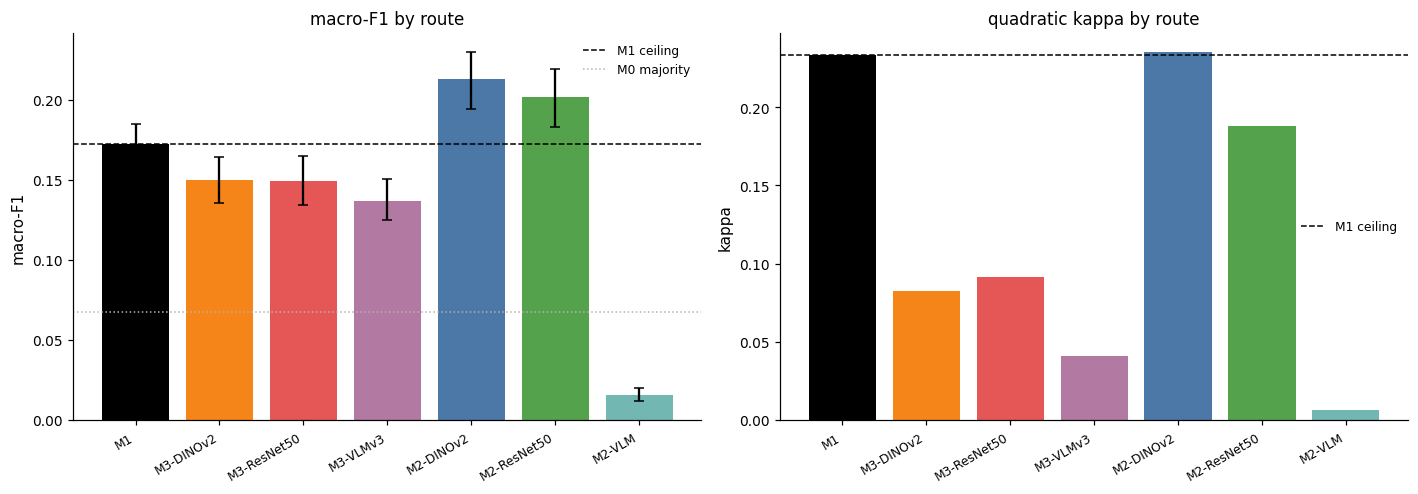

In [3]:
plot_routes = [r for r in ROUTES if r != 'M0']
colors = [ROUTE_COLORS[r] for r in plot_routes]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

mf = [M[r]['macro_f1'] for r in plot_routes]
lo = [M[r]['macro_f1']-M[r]['bootstrap_95ci']['macro_f1']['lo'] for r in plot_routes]
hi = [M[r]['bootstrap_95ci']['macro_f1']['hi']-M[r]['macro_f1'] for r in plot_routes]
axes[0].bar(range(len(plot_routes)), mf, color=colors, yerr=[lo, hi], capsize=3)
axes[0].axhline(M['M1']['macro_f1'], color='black', ls='--', lw=1, label='M1 ceiling')
axes[0].axhline(M['M0']['macro_f1'], color='#BAB0AC', ls=':', lw=1, label='M0 majority')
axes[0].set_title('macro-F1 by route'); axes[0].set_ylabel('macro-F1')
axes[0].set_xticks(range(len(plot_routes))); axes[0].set_xticklabels(plot_routes, rotation=30, ha='right', fontsize=8)
axes[0].legend(frameon=False, fontsize=8)

kp = [M[r]['quadratic_kappa'] for r in plot_routes]
axes[1].bar(range(len(plot_routes)), kp, color=colors)
axes[1].axhline(M['M1']['quadratic_kappa'], color='black', ls='--', lw=1, label='M1 ceiling')
axes[1].set_title('quadratic kappa by route'); axes[1].set_ylabel('kappa')
axes[1].set_xticks(range(len(plot_routes))); axes[1].set_xticklabels(plot_routes, rotation=30, ha='right', fontsize=8)
axes[1].legend(frameon=False, fontsize=8)
fig.tight_layout()
save_fig(fig, 'F1_route_comparison')
plt.show()

### Reading

Trained end-to-end M2 (DINOv2/ResNet) match the M1 ceiling and beat their decomposed M3; M2-VLM (zero-shot) collapses. The decomposition — not the vision backbone — is the binding constraint.

## 3. Confusion matrices: M1 (GT ceiling) vs best M2

[fig] reports\figures\stage3\F2_confusion_M1_vs_M2.png  +  F2_confusion_M1_vs_M2.pdf


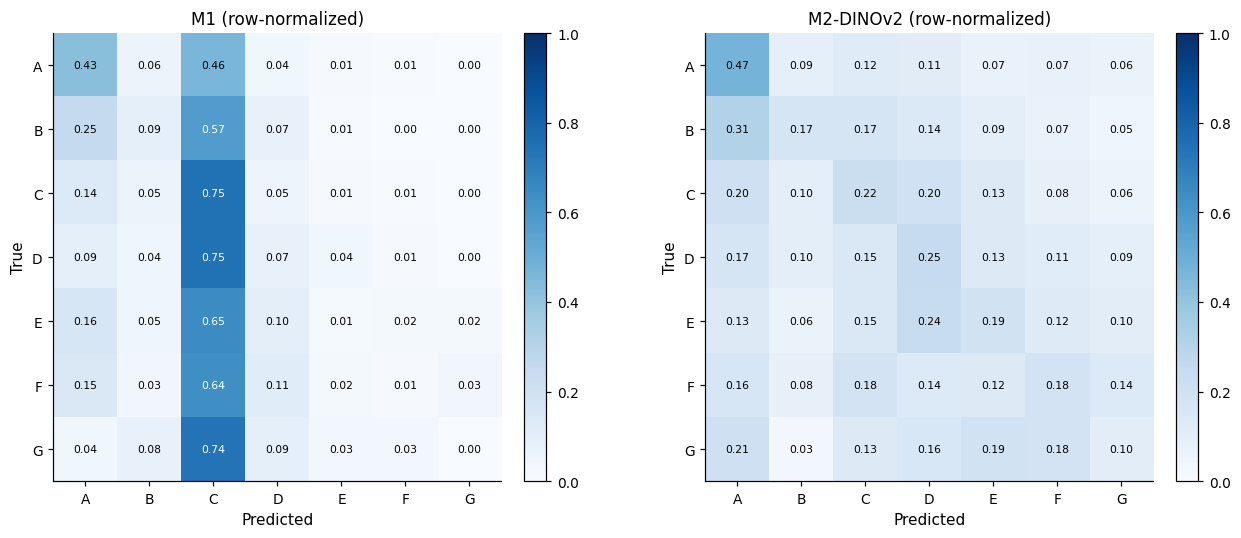

best M2 = M2-DINOv2


In [4]:
best_m2 = max(['M2-DINOv2','M2-ResNet50','M2-VLM'], key=lambda r: M[r]['macro_f1'])
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, r in zip(axes, ['M1', best_m2]):
    cm = np.asarray(M[r]['confusion_matrix']['matrix'])
    confusion_heatmap(cm, ENERGY_LABELS, ax, title=f'{r} (row-normalized)')
fig.tight_layout()
save_fig(fig, 'F2_confusion_M1_vs_M2')
plt.show()
print('best M2 =', best_m2)

## 4. Error propagation (best M3)

Of the misclassified buildings on the best decomposed route, how many errors are attributable to vision attribute mistakes vs the downstream classifier (attributes correct, label still wrong)?

[fig] reports\figures\stage3\F3_error_propagation.png  +  F3_error_propagation.pdf


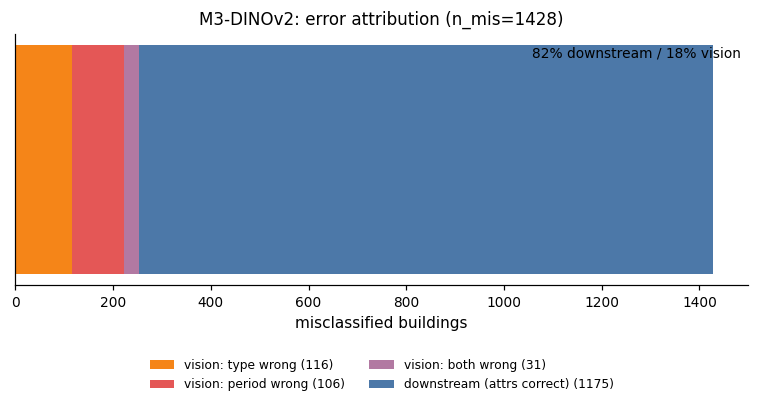

In [5]:
ep = json.loads((REPORTS_DIR / 'error_propagation.json').read_text())
fig, ax = plt.subplots(figsize=(7, 4))
segs = [('vision: type wrong', ep['type_wrong']-ep['both_wrong'], '#F58518'),
        ('vision: period wrong', ep['period_wrong']-ep['both_wrong'], '#E45756'),
        ('vision: both wrong', ep['both_wrong'], '#B279A2'),
        ('downstream (attrs correct)', ep['attrs_correct_downstream_error'], '#4C78A8')]
left = 0
for label, val, c in segs:
    ax.barh(0, val, left=left, color=c, label=f'{label} ({val})')
    left += val
ax.set_yticks([]); ax.set_xlabel('misclassified buildings')
ax.set_title(f"{ep['best_m3']}: error attribution (n_mis={ep['n_misclassified']})")
ax.legend(frameon=False, fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=2)
frac = ep['attrs_correct_downstream_error']/ep['n_misclassified']
ax.text(0.99, 0.95, f'{frac:.0%} downstream / {1-frac:.0%} vision',
        transform=ax.transAxes, ha='right', va='top', fontsize=9)
fig.tight_layout()
save_fig(fig, 'F3_error_propagation')
plt.show()